# 📔 Pre-Workshop Notebook 5: Finding Patterns in Brain and Behavioral Data
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your progress.*

In [ ]:
# PROFILE SYNC
student_name = "Dr. Evie A. Malaia"
institution = "University of Alabama"
active_notebook = "Notebook 05 — Pattern Recognition and Analysis"

print(f"✅ Profile synced for {student_name} ({institution})")
print(f"Current notebook: {active_notebook}")

---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** working with machine learning tools, your main risk is accidentally mixing up the data you use to train a model with the data you use to test it. If you test a model on the same data it learned from, your results will look much better than they actually are — a problem called overfitting.

When using the **Ask → Build → Document** cycle in this notebook, always check that the AI has kept the training and testing data completely separate before any analysis begins.

---
## 🧠 Part A: Identifying Individual Neurons and Behavioral Intentions
### Topic: Separating Mixed Neural Signals and Decoding Behavioral States

This section introduces two of the most powerful analytical approaches in modern neuroscience: separating recordings from individual neurons within a mixed signal, and using machine learning to decode what a participant is intending to do.

### 🧭 Activity A.1 — Separating Signals from Individual Neurons

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a computational neuroscience instructor explaining neural signal analysis to a biology student. Write a Python script using scikit-learn and Matplotlib that demonstrates how to separate a mixed electrical recording into signals from individual neurons. The script should:
> 1. Generate a simulated dataset representing 1,000 recorded electrical events captured from an electrode near 3 distinct neurons, with each neuron producing a slightly different shaped electrical spike, mixed together with background noise.
> 2. Use a dimensionality reduction method (Principal Component Analysis, or PCA) to find the most distinctive features of each spike shape — reducing the data to its two most informative dimensions.
> 3. Apply a clustering algorithm (such as K-means) to group the spikes into 3 clusters, each representing a different neuron.
> 4. Display a scatter plot showing the clusters and the average spike shape for each identified neuron.
> Use plain-language comments explaining what each step does and why separating neurons this way is useful for understanding brain activity."

SIMULATED NEURAL SPIKE SORTING

Recorded electrical events: 1000
Simulated neurons:           3
Samples per spike waveform:  60

Generated mixed recording containing spikes from three different neurons.

Running PCA...
Original spike dimensions: 60
PCA dimensions:            2
Variance explained by the two PCA dimensions: 67.9%

Running K-means clustering...


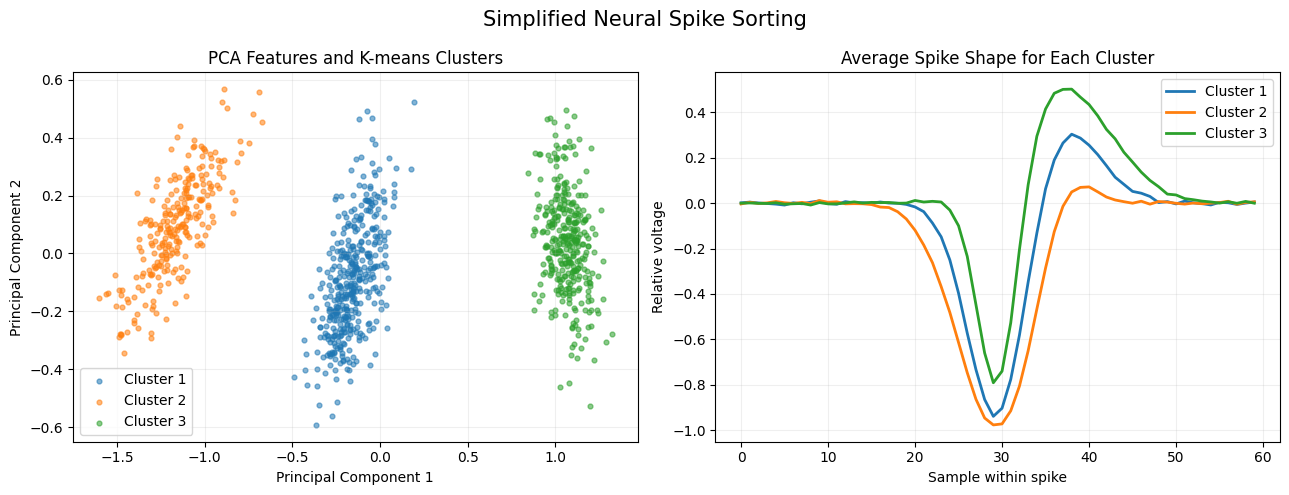


SPIKE-SORTING SUMMARY
Cluster 1: 402 spikes
Cluster 2: 257 spikes
Cluster 3: 341 spikes

The PCA step compressed each 60-sample spike into two
informative features.

The K-means step then grouped spikes with similar features.

The average waveform of each cluster provides an estimate of
the characteristic spike shape associated with that group.

Why is this useful?

An electrode can record electrical activity from several nearby
neurons at the same time. Separating those spikes lets researchers
study the firing patterns of individual neurons rather than
treating the entire recording as one signal.

In real neuroscience experiments, researchers also perform
quality control, noise removal, waveform alignment, cluster
validation, and often use more advanced spike-sorting algorithms.
The three clusters produced here should therefore be viewed as
a teaching demonstration rather than definitive identification
of real neurons.



In [1]:
# 💻 Activity A.1 — Paste your AI-generated Neural Signal Separation code here:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# ============================================================
# Simulated neural spike sorting with PCA + K-means
# ============================================================
#
# Imagine an electrode placed near several neurons.
#
# The electrode does NOT automatically know which neuron
# produced each electrical spike. Instead, it records a mixture:
#
#       Neuron A spike
#       Neuron B spike
#       Neuron C spike
#             +
#       background noise
#
# Our goal is to separate the 1,000 recorded spikes into
# three groups corresponding to the three simulated neurons.
#
# This general process is called "spike sorting."
#
# We will use:
#
#   PCA      -> reduce each spike shape to 2 useful features
#   K-means  -> group similar spike shapes into 3 clusters
# ============================================================


# ------------------------------------------------------------
# 1. Set up the simulation
# ------------------------------------------------------------

N_SPIKES = 1000
N_NEURONS = 3
N_SAMPLES_PER_SPIKE = 60

rng = np.random.default_rng(42)

print("=" * 65)
print("SIMULATED NEURAL SPIKE SORTING")
print("=" * 65)

print(
    f"\nRecorded electrical events: {N_SPIKES}"
)

print(
    f"Simulated neurons:           {N_NEURONS}"
)

print(
    f"Samples per spike waveform:  {N_SAMPLES_PER_SPIKE}"
)


# ------------------------------------------------------------
# 2. Create three different neuron spike shapes
# ------------------------------------------------------------
#
# Real neurons can produce extracellular spikes with somewhat
# different shapes because of differences in their electrical
# properties and their locations relative to the electrode.
#
# We simulate three distinctive waveforms.
# ------------------------------------------------------------

x = np.linspace(
    -1,
    1,
    N_SAMPLES_PER_SPIKE
)


def make_spike_shape(
    negative_width,
    positive_width,
    positive_amplitude
):
    """
    Create a simplified extracellular spike.

    The first component is a negative deflection and the second
    is a smaller positive deflection.

    This is only a mathematical model of a spike waveform;
    real extracellular spikes can be considerably more complex.
    """

    negative_part = -np.exp(
        -(x / negative_width) ** 2
    )

    positive_part = (
        positive_amplitude
        * np.exp(
            -((x - 0.25) / positive_width) ** 2
        )
    )

    return negative_part + positive_part


# Three neurons have slightly different spike shapes.

neuron_shapes = np.array([
    make_spike_shape(
        0.16,
        0.20,
        0.35
    ),

    make_spike_shape(
        0.11,
        0.27,
        0.50
    ),

    make_spike_shape(
        0.22,
        0.14,
        0.25
    )
])


# ------------------------------------------------------------
# 3. Decide which neuron produced each recorded spike
# ------------------------------------------------------------

# Each recorded event is assigned to one of the three neurons.
#
# The probabilities do not have to be equal. Here we make
# neuron 1 slightly more common than the others.
true_neuron = rng.choice(
    N_NEURONS,
    size=N_SPIKES,
    p=[0.40, 0.35, 0.25]
)


# ------------------------------------------------------------
# 4. Generate the mixed recording
# ------------------------------------------------------------

# Every row will contain one recorded spike waveform.
#
# Shape:
#
#       1,000 spikes × 60 samples per spike
#
# The electrode sees a noisy version of the spike generated by
# whichever neuron produced that event.
spikes = np.zeros(
    (
        N_SPIKES,
        N_SAMPLES_PER_SPIKE
    )
)

for i in range(N_SPIKES):

    neuron = true_neuron[i]

    # Start with that neuron's characteristic spike shape.
    spike = neuron_shapes[neuron].copy()

    # Give each spike a small amplitude variation.
    # Real biological recordings are not perfectly identical.
    amplitude = rng.normal(
        1.0,
        0.08
    )

    spike *= amplitude

    # Add random recording noise.
    noise = rng.normal(
        0,
        0.08,
        N_SAMPLES_PER_SPIKE
    )

    spikes[i] = spike + noise


print(
    "\nGenerated mixed recording containing spikes from "
    "three different neurons."
)


# ------------------------------------------------------------
# 5. Use PCA to find important features
# ------------------------------------------------------------
#
# Each spike contains 60 measurements.
#
# Instead of working with all 60 measurements, PCA finds
# combinations of measurements that explain the largest
# differences between spike shapes.
#
# We keep only the first two principal components.
#
# So each 60-point spike becomes:
#
#       [PC1, PC2]
#
# These two numbers summarize important differences in its shape.
# ------------------------------------------------------------

print("\nRunning PCA...")

pca = PCA(
    n_components=2
)

spikes_2d = pca.fit_transform(
    spikes
)

print(
    f"Original spike dimensions: "
    f"{N_SAMPLES_PER_SPIKE}"
)

print(
    f"PCA dimensions:            "
    f"{spikes_2d.shape[1]}"
)

print(
    "Variance explained by the two PCA dimensions: "
    f"{pca.explained_variance_ratio_.sum() * 100:.1f}%"
)


# ------------------------------------------------------------
# 6. Cluster the PCA features
# ------------------------------------------------------------
#
# K-means looks for groups of points that are close together.
#
# We tell it to look for 3 groups because our simulation
# contains three neurons.
#
# Importantly, K-means does NOT know the true neuron identity.
# It only sees the spike features.
# ------------------------------------------------------------

print("\nRunning K-means clustering...")

kmeans = KMeans(
    n_clusters=N_NEURONS,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    spikes_2d
)


# ------------------------------------------------------------
# 7. Calculate the average spike shape for each cluster
# ------------------------------------------------------------
#
# Once K-means has assigned each spike to a cluster, we can
# average the waveforms within each cluster.
#
# The resulting average waveform gives us an estimate of the
# characteristic spike shape for that group.
# ------------------------------------------------------------

average_spikes = []

for cluster in range(N_NEURONS):

    cluster_spikes = spikes[
        cluster_labels == cluster
    ]

    average_spike = np.mean(
        cluster_spikes,
        axis=0
    )

    average_spikes.append(
        average_spike
    )

average_spikes = np.array(
    average_spikes
)


# ------------------------------------------------------------
# 8. Display the PCA clusters and average waveforms
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


# ============================================================
# Left plot: PCA space
# ============================================================

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green"
]

for cluster in range(N_NEURONS):

    points = spikes_2d[
        cluster_labels == cluster
    ]

    axes[0].scatter(
        points[:, 0],
        points[:, 1],
        s=12,
        alpha=0.55,
        color=colors[cluster],
        label=f"Cluster {cluster + 1}"
    )

axes[0].set_title(
    "PCA Features and K-means Clusters"
)

axes[0].set_xlabel(
    "Principal Component 1"
)

axes[0].set_ylabel(
    "Principal Component 2"
)

axes[0].legend()

axes[0].grid(
    alpha=0.2
)


# ============================================================
# Right plot: Average spike shapes
# ============================================================

for cluster in range(N_NEURONS):

    axes[1].plot(
        average_spikes[cluster],
        linewidth=2,
        color=colors[cluster],
        label=f"Cluster {cluster + 1}"
    )

axes[1].set_title(
    "Average Spike Shape for Each Cluster"
)

axes[1].set_xlabel(
    "Sample within spike"
)

axes[1].set_ylabel(
    "Relative voltage"
)

axes[1].legend()

axes[1].grid(
    alpha=0.2
)


plt.suptitle(
    "Simplified Neural Spike Sorting",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "neural_spike_sorting.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 9. Print a simple summary
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SPIKE-SORTING SUMMARY")
print("=" * 65)

for cluster in range(N_NEURONS):

    count = np.sum(
        cluster_labels == cluster
    )

    print(
        f"Cluster {cluster + 1}: "
        f"{count} spikes"
    )

print(
    """
The PCA step compressed each 60-sample spike into two
informative features.

The K-means step then grouped spikes with similar features.

The average waveform of each cluster provides an estimate of
the characteristic spike shape associated with that group.

Why is this useful?

An electrode can record electrical activity from several nearby
neurons at the same time. Separating those spikes lets researchers
study the firing patterns of individual neurons rather than
treating the entire recording as one signal.

In real neuroscience experiments, researchers also perform
quality control, noise removal, waveform alignment, cluster
validation, and often use more advanced spike-sorting algorithms.
The three clusters produced here should therefore be viewed as
a teaching demonstration rather than definitive identification
of real neurons.
"""
)


### 🧭 Activity A.2 — Predicting Behavioral Intentions from Brain Signals

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a machine learning instructor teaching a neuroscience student how to decode behavioral intentions from brain signals. Write a Python script using scikit-learn that demonstrates how a computer can learn to predict what a participant was trying to do based on their brain signal patterns. The script should:
> 1. Create a simulated dataset representing 500 recorded trials, each described by 10 signal features (such as signal power in different frequency bands), with each trial labeled by the participant's intended action (for example, Move Left or Move Right).
> 2. Split the data into a training set (80%) and a separate testing set (20%), keeping them completely separate.
> 3. Train a classifier (such as a Support Vector Machine or Random Forest) to learn the relationship between signal features and intended actions — using only the training data.
> 4. Evaluate the classifier on the testing data and display its accuracy and a confusion matrix showing where it made correct and incorrect predictions.
> Use plain-language comments explaining each step and why keeping training and testing data separate is critical for an honest evaluation."

BRAIN-SIGNAL DECODING WITH MACHINE LEARNING

Creating 500 simulated trials...
Each trial has 10 signal features.

Dataset shape: (500, 10)
Shape means: 500 trials × 10 signal features

Training trials: 400
Testing trials:  100

Training SVM classifier...
Training complete.

Predicting intentions for test trials...

MODEL PERFORMANCE

Test accuracy: 92.0%
The model correctly classified approximately 92.0% of previously unseen trials.

Confusion matrix:
[[47  4]
 [ 4 45]]


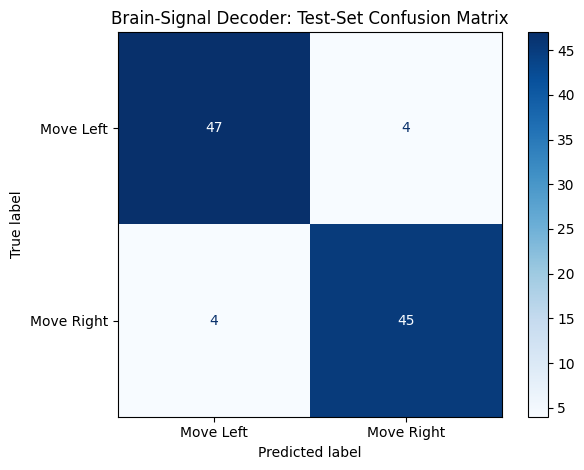


WHAT THIS DEMONSTRATES

The workflow was:

    Brain signals
          ↓
    10 signal features
          ↓
    80% training data
          ↓
    SVM learns the relationship
          ↓
    20% previously unseen test data
          ↓
    Predicted intention

The most important experimental-design principle is keeping
training and testing data separate.

If we allowed the model to train on the test trials and then
evaluated it on those same trials, the accuracy could look
artificially high. We would no longer have an honest test of
whether the decoder can generalize to new brain recordings.

The confusion matrix provides additional information beyond
overall accuracy. It shows how many Left and Right trials were
correctly classified and where the model confused one intention
with the other.

In a real brain-computer interface, the same general idea could
be used to decode intended movements from neural features, but
researchers would also need careful cross-validation, artifact
handlin

In [2]:
# 💻 Activity A.2 — Paste your AI-generated Behavioral Decoding code here:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# ============================================================
# Brain-signal decoding demonstration
# ============================================================
#
# Goal:
#   Predict whether a participant intended to:
#
#       0 = Move Left
#       1 = Move Right
#
# based on 10 simulated features extracted from their brain
# signals.
#
# In a real neuroscience experiment, these features might
# represent things such as:
#
#   - power in different frequency bands
#   - activity from different electrodes
#   - firing rates
#   - other measurements extracted from neural recordings
#
# This is a simplified demonstration. Real brain-computer
# interface datasets are much more complicated.
# ============================================================


# ------------------------------------------------------------
# 1. Generate the simulated dataset
# ------------------------------------------------------------

N_TRIALS = 500
N_FEATURES = 10

rng = np.random.default_rng(42)

print("=" * 65)
print("BRAIN-SIGNAL DECODING WITH MACHINE LEARNING")
print("=" * 65)

print(
    f"\nCreating {N_TRIALS} simulated trials..."
)

print(
    f"Each trial has {N_FEATURES} signal features."
)


# ------------------------------------------------------------
# Create the intended-action labels
# ------------------------------------------------------------
#
# Each trial has one known behavioral intention:
#
#   0 -> Move Left
#   1 -> Move Right
#
# In a real experiment, these labels might come from the
# instruction given to the participant or the movement they
# actually performed.
# ------------------------------------------------------------

y = rng.integers(
    0,
    2,
    size=N_TRIALS
)


# ------------------------------------------------------------
# Generate brain-signal features
# ------------------------------------------------------------
#
# Start with random background variation.
#
# Then we add systematic differences between Left and Right
# trials. This represents the idea that neural activity can
# contain information about a participant's intended action.
# ------------------------------------------------------------

X = rng.normal(
    loc=0,
    scale=1,
    size=(N_TRIALS, N_FEATURES)
)


# Give the two actions somewhat different signal patterns.
#
# These differences are deliberately subtle rather than
# perfectly separated, making the classification task more
# realistic.

left_trials = y == 0
right_trials = y == 1

# Imagine these first few features represent different
# frequency-band powers or electrode measurements.

X[left_trials, 0] -= 1.0
X[left_trials, 1] -= 0.7
X[left_trials, 2] += 0.5

X[right_trials, 0] += 1.0
X[right_trials, 1] += 0.7
X[right_trials, 2] -= 0.5


print(
    f"\nDataset shape: {X.shape}"
)

print(
    "Shape means: 500 trials × 10 signal features"
)


# ------------------------------------------------------------
# 2. Split the data into training and testing sets
# ------------------------------------------------------------
#
# This is one of the most important steps in machine learning.
#
# 80% of the trials will be used to TRAIN the classifier.
#
# The remaining 20% will be held aside as TEST data.
#
# The classifier must not see the test data while learning.
#
# Why?
#
# If we tested the model on the same data it learned from,
# we could get an overly optimistic accuracy. The model might
# simply memorize patterns in those particular trials.
#
# Keeping the test data separate gives us a better estimate
# of how the model might perform on NEW trials.
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print(
    f"\nTraining trials: {len(X_train)}"
)

print(
    f"Testing trials:  {len(X_test)}"
)


# ------------------------------------------------------------
# 3. Standardize the features
# ------------------------------------------------------------
#
# Different brain-signal features can have very different
# numerical scales.
#
# Standardization puts them onto a comparable scale.
#
# IMPORTANT:
#
# We calculate the scaling parameters using ONLY the training
# data. The test data is then transformed using those same
# training-derived parameters.
#
# This prevents information from the test set from leaking
# into the training process.
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# ------------------------------------------------------------
# 4. Train the classifier
# ------------------------------------------------------------
#
# We use a Support Vector Machine (SVM).
#
# The SVM looks for a decision boundary that separates the
# patterns associated with Move Left and Move Right.
#
# The model sees ONLY X_train and y_train.
# ------------------------------------------------------------

print("\nTraining SVM classifier...")

classifier = SVC(
    kernel="linear",
    random_state=42
)

classifier.fit(
    X_train_scaled,
    y_train
)


print(
    "Training complete."
)


# ------------------------------------------------------------
# 5. Test the trained classifier
# ------------------------------------------------------------
#
# Now we give the model the completely separate test trials.
#
# The correct answers (y_test) were kept hidden from the
# classifier during training.
# ------------------------------------------------------------

print("\nPredicting intentions for test trials...")

y_pred = classifier.predict(
    X_test_scaled
)


# ------------------------------------------------------------
# 6. Calculate classification accuracy
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 65)
print("MODEL PERFORMANCE")
print("=" * 65)

print(
    f"\nTest accuracy: {accuracy * 100:.1f}%"
)

print(
    f"The model correctly classified approximately "
    f"{accuracy * 100:.1f}% of previously unseen trials."
)


# ------------------------------------------------------------
# 7. Create a confusion matrix
# ------------------------------------------------------------
#
# A confusion matrix gives more detail than accuracy alone.
#
# Rows represent the participant's TRUE intended action.
# Columns represent what the computer PREDICTED.
#
# For example:
#
#       True Left   Predicted Left
#       True Left   Predicted Right
#
# This lets us see which types of mistakes the model makes.
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion matrix:")
print(cm)


# ------------------------------------------------------------
# 8. Display the confusion matrix
# ------------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Move Left",
        "Move Right"
    ]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Brain-Signal Decoder: Test-Set Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    "brain_signal_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 9. Final explanation
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("WHAT THIS DEMONSTRATES")
print("=" * 65)

print(
    """
The workflow was:

    Brain signals
          ↓
    10 signal features
          ↓
    80% training data
          ↓
    SVM learns the relationship
          ↓
    20% previously unseen test data
          ↓
    Predicted intention

The most important experimental-design principle is keeping
training and testing data separate.

If we allowed the model to train on the test trials and then
evaluated it on those same trials, the accuracy could look
artificially high. We would no longer have an honest test of
whether the decoder can generalize to new brain recordings.

The confusion matrix provides additional information beyond
overall accuracy. It shows how many Left and Right trials were
correctly classified and where the model confused one intention
with the other.

In a real brain-computer interface, the same general idea could
be used to decode intended movements from neural features, but
researchers would also need careful cross-validation, artifact
handling, feature selection, and testing on appropriately
independent participants or recording sessions.
"""
)


### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** From Activity A.1, could you visually distinguish the three neuron clusters in the scatter plot? From Activity A.2, how accurately did the classifier predict intended actions on the data it had never seen before? - yep! 92%
* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 22, 23, 24, and 25** from your Reference Guide. Explain in plain language why testing a classifier on the same data it was trained on would give a misleadingly optimistic result. - because you have no idea based on what the classifier works, and if NEW data would be correctly classified due to data leakage!

---

## 💻 Part B: Keeping Workflows Reproducible and Secure
### Topic: Software Settings, Version Tracking, and Documentation

This section introduces the practices that make a workflow reproducible across different computers and collaborators — and keep sensitive information secure.

### 🧭 Activity B.1 — Documenting Your Software Environment

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research reproducibility instructor. Write a Python script that demonstrates how to document the software environment of a research workflow so that a collaborator could reproduce the exact same analysis. The script should:
> 1. Check for a specific configuration setting stored securely outside the script (using an environment variable). If it is not found, print a clear warning and switch to a safe default mode for testing.
> 2. Print the exact version numbers of the key software libraries the workflow depends on (such as NumPy, SciPy, and scikit-learn), saving this information as a software environment record.
> 3. Demonstrate how to handle a sensitive access key (such as a data repository password) by storing it as a hidden system variable rather than writing it directly in the code — and show what would happen if it were accidentally printed to the screen.
> Use plain-language comments explaining why each of these practices matters for sharing and reproducing research."

In [3]:
# 💻 Activity B.1 — Paste your AI-generated Software Environment Documentation code here:
import os
import sys
import platform
from datetime import datetime

import numpy as np
import scipy
import sklearn


# ============================================================
# Research software environment record
# ============================================================
#
# Reproducible research means that another researcher should
# be able to determine which software environment was used.
#
# Library versions can affect numerical results, so recording
# them is an important part of documenting an analysis.
#
# Sensitive information, such as passwords and access keys,
# should NOT be stored in this Python file. Instead, we read
# them from environment variables supplied by the operating
# system.
# ============================================================


# ------------------------------------------------------------
# 1. Read a configuration setting from the environment
# ------------------------------------------------------------
#
# Suppose our workflow has two modes:
#
#   PRODUCTION -> use real research data
#   TEST       -> use simulated/test data
#
# We do not hard-code this setting in the script. This allows
# the same program to be used in different environments without
# editing the source code.
#
# The researcher can set:
#
#   ANALYSIS_MODE=production
#
# in their operating-system environment.
# ------------------------------------------------------------

analysis_mode = os.environ.get(
    "ANALYSIS_MODE"
)


if analysis_mode is None:

    print(
        "WARNING: ANALYSIS_MODE was not found."
    )

    print(
        "Switching to safe TEST mode."
    )

    analysis_mode = "test"

else:

    print(
        f"Analysis mode: {analysis_mode}"
    )


# Only accept the two modes we expect.
if analysis_mode.lower() not in {
    "test",
    "production"
}:

    print(
        "WARNING: Unknown ANALYSIS_MODE value."
    )

    print(
        "Switching to safe TEST mode."
    )

    analysis_mode = "test"


# ------------------------------------------------------------
# 2. Read the sensitive access key
# ------------------------------------------------------------
#
# IMPORTANT:
#
# Never write something like this in your source code:
#
#     DATA_ACCESS_KEY = "my-secret-password"
#
# Source code is often shared through Git repositories,
# email, cloud storage, or collaboration platforms.
#
# Instead, the operating system stores the secret and the
# program reads it when needed.
#
# For this demonstration, the expected variable is:
#
#     RESEARCH_DATA_ACCESS_KEY
#
# If it isn't present, we simply operate without the key.
# ------------------------------------------------------------

access_key = os.environ.get(
    "RESEARCH_DATA_ACCESS_KEY"
)


if access_key is None:

    print(
        "\nNo research access key was found."
    )

    print(
        "Continuing in test mode without private data access."
    )

else:

    print(
        "\nResearch access key detected."
    )

    # We intentionally DO NOT print the actual key.
    #
    # Even if a key exists, showing it on screen could expose
    # a secret in terminal history, screenshots, log files,
    # notebooks, or automated job records.

    print(
        "Access key value: [HIDDEN]"
    )


# ------------------------------------------------------------
# 3. Demonstrate what NOT to do
# ------------------------------------------------------------
#
# The following code is intentionally NOT executed:
#
#     print(access_key)
#
# If it were executed, the secret would appear on the screen.
# It could then accidentally be copied into:
#
#   - a terminal log
#   - a notebook
#   - a screenshot
#   - a research report
#   - an automated job log
#
# Even though environment variables keep secrets out of the
# source code, they are NOT magically safe if the program
# prints them.
# ------------------------------------------------------------

print(
    "\nSECURITY NOTE:"
)

print(
    "Never use print(access_key) in a real research workflow."
)

print(
    "This demonstration deliberately keeps the secret hidden."
)


# ------------------------------------------------------------
# 4. Collect software-environment information
# ------------------------------------------------------------
#
# We record:
#
#   - Python version
#   - operating system
#   - NumPy version
#   - SciPy version
#   - scikit-learn version
#
# These details help another researcher understand which
# computational environment produced the analysis.
# ------------------------------------------------------------

environment_record = {
    "recorded_at": datetime.now().isoformat(),
    "python_version": sys.version,
    "operating_system": platform.platform(),
    "numpy_version": np.__version__,
    "scipy_version": scipy.__version__,
    "scikit_learn_version": sklearn.__version__,
    "analysis_mode": analysis_mode,
}


# ------------------------------------------------------------
# 5. Display the environment information
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SOFTWARE ENVIRONMENT")
print("=" * 65)

for name, value in environment_record.items():

    print(
        f"{name}: {value}"
    )


# ------------------------------------------------------------
# 6. Save the environment record
# ------------------------------------------------------------
#
# Saving this information to a file creates a simple record
# that can accompany the research results.
#
# Notice that we DO NOT save the access key.
#
# Software versions are useful reproducibility information.
# Passwords and access keys are security information and should
# remain private.
# ------------------------------------------------------------

record_filename = "software_environment_record.txt"

with open(
    record_filename,
    "w"
) as file:

    file.write(
        "Research Software Environment Record\n"
    )

    file.write(
        "=" * 50 + "\n"
    )

    for name, value in environment_record.items():

        file.write(
            f"{name}: {value}\n"
        )


print(
    f"\nEnvironment record saved to: "
    f"{record_filename}"
)


# ------------------------------------------------------------
# 7. Show the configuration that would be used
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("WORKFLOW CONFIGURATION")
print("=" * 65)

if analysis_mode.lower() == "test":

    print(
        "TEST mode: using simulated/test data."
    )

    print(
        "This is the safe fallback when production configuration "
        "is unavailable."
    )

else:

    print(
        "PRODUCTION mode: real research-data workflow selected."
    )

    if access_key is None:

        print(
            "WARNING: Production mode was requested, but no "
            "access key is available."
        )

        print(
            "A real workflow should stop before attempting "
            "private-data access."
        )

    else:

        print(
            "Private-data credential is available "
            "without displaying its value."
        )


# ------------------------------------------------------------
# Final explanation
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("REPRODUCIBILITY LESSON")
print("=" * 65)

print(
    """
Three practices are demonstrated here:

1. CONFIGURATION OUTSIDE THE CODE
   Environment variables let the same script run in different
   environments without changing the source code. If a required
   setting is missing, the workflow uses a safe testing mode
   instead of making an unsafe assumption.

2. SOFTWARE VERSION RECORDING
   NumPy, SciPy, scikit-learn, Python, and the operating system
   are recorded. Another researcher can use this information
   when rebuilding the analysis environment.

3. SECRETS STAY OUT OF SOURCE CODE
   Access keys and passwords should be supplied through a secure
   environment or secret-management system rather than being
   written into the Python script.

   The program can use a secret without printing it. Accidentally
   printing the secret could expose it through terminal logs,
   notebooks, screenshots, or automated computing records.

For a real project, the environment record would usually be
supplemented with a pinned dependency file such as requirements.txt
or a conda/environment specification so that the software
environment can be recreated more precisely.
"""
)


Switching to safe TEST mode.

No research access key was found.
Continuing in test mode without private data access.

SECURITY NOTE:
Never use print(access_key) in a real research workflow.
This demonstration deliberately keeps the secret hidden.

SOFTWARE ENVIRONMENT
recorded_at: 2026-08-13T14:49:36.003089
python_version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
operating_system: Linux-6.6.122+-x86_64-with-glibc2.35
numpy_version: 2.0.2
scipy_version: 1.16.3
scikit_learn_version: 1.6.1
analysis_mode: test

Environment record saved to: software_environment_record.txt

WORKFLOW CONFIGURATION
TEST mode: using simulated/test data.
This is the safe fallback when production configuration is unavailable.

REPRODUCIBILITY LESSON

Three practices are demonstrated here:

1. CONFIGURATION OUTSIDE THE CODE
   Environment variables let the same script run in different
   environments without changing the source code. If a required
   setting is missing, the workflow uses a safe testing m

### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** What did the script do when the configuration setting was missing? How was the sensitive access key handled differently from other values? - The script printed a warning and automatically switched to a safe testing mode. The sensitive access key was looked up in an environment variable. The key was never printed or saved in the software-environment record.
* **Connecting to key concepts:** Activity B.1 demonstrates **Concepts 44, 46, and 48** from your Reference Guide. Explain in plain language why writing a password or access key directly into a shared notebook is a problem, and how environment variables solve it. - Writing a password or access key directly into a shared notebook is dangerous because notebooks are shared, backed up, committed to Git, or included with research results.

---

## 📑 What Comes Next

Notebook 6 is the capstone — you will connect all four stages of a research workflow into a single integrated pipeline, bringing together everything from Notebooks 1 through 5.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all six pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 22 — Spike sorting | [ Enter Cell ID ] |
| Neuroscience | Concept 23 — Machine learning for neural decoding | [ Enter Cell ID ] |
| Neuroscience | Concept 24 — Sensory feedback | [ Enter Cell ID ] |
| Computing | Concept 44 — Hidden configuration settings | [ Enter Cell ID ] |
| Computing | Concept 46 — Code version tracking | [ Enter Cell ID ] |
| Computing | Concept 48 — Data arrays | [ Enter Cell ID ] |
